In [1]:
print("Hello World")

Hello World


In [2]:
import torch
print(torch.__version__)

2.6.0+cu124


In [4]:
t = torch.tensor([[1, 2], [3, 4]])
print(t)

tensor([[1, 2],
        [3, 4]])


In [5]:
print(t.shape)

torch.Size([2, 2])


In [6]:
import pandas
import numpy
print(pandas.__version__)
print(numpy.__version__)

2.0.0
1.26.4


In [7]:
# 檢查GPU資訊
import torch

print(f"Is CUDA available? {torch.cuda.is_available()}") # 看PyTorch是否有抓到GPU
print(f"GPU name: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(device)


Is CUDA available? True
GPU name: NVIDIA GeForce GTX 1080 Ti
cuda:0


In [8]:
import transformers
print(transformers.__version__)

4.48.3


In [9]:
# 檢查需要的套件版本，看看是否需要更新版本
import pandas as pd
import torch
import transformers
print(pd.__version__)
print(torch.__version__)
print(transformers.__version__)

2.0.0
2.6.0+cu124
4.48.3


In [10]:
# 簡單操作一下transformers的tokenizer
from transformers import AutoTokenizer
import torch
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print(tokenizer.model_max_length) # 模型最多可以接受的input sequence長度
print(tokenizer.vocab_size) # Bert的vocabulary大小
print(tokenizer.vocab) # 印出所有vocabulary，token以及對應ID
print(tokenizer.special_tokens_map) # 印出所有special tokens
print(tokenizer.vocab['[CLS]'])  # 取得[CLS] token在vocabulary中的ID，CLS會在每個input最前面，用來處理分類問題
print(tokenizer.vocab['[SEP]']) # 取得[SEP] token在vocabulary中的ID，SEP用來隔開句子，出現在每個句子最後面
print(tokenizer.vocab['[PAD]']) # 取得[PAD] token在vocabulary中的ID，PAD用來補0

# tokenization範例
s1 = "Hello World! How are you"
s1_encoding = tokenizer(s1, truncation=True, padding=True, max_length=300)
print(s1_encoding)
print(s1_encoding.keys())
print(s1_encoding.items())
for key, val in s1_encoding.items():
  print(key, val)

# 取得指定的index內容
item = {key: torch.tensor(val[2]) for key, val in s1_encoding.items()}
print(item)

512
30522
{'police': 2610, '##valent': 24879, 'regulator': 21618, 'rec': 28667, 'vo': 29536, 'smoked': 20482, 'gov': 18079, 'outlet': 13307, '##virus': 23350, 'unease': 27880, 'tentative': 19943, 'concerto': 10405, 'cdc': 26629, 'banker': 13448, 'renaming': 24944, '##դ': 29769, 'combatants': 26622, 'depending': 5834, 'freshwater': 12573, '##mun': 23041, 'specialist': 8325, '[unused866]': 871, '##uan': 13860, 'gershwin': 25600, 'damon': 11317, '##avi': 18891, '##kki': 24103, 'arm': 2849, 'baptism': 18336, 'chosen': 4217, 'gum': 16031, 'volunteered': 14382, 'ellie': 10707, 'sheikh': 12840, '##ula': 7068, 'munoz': 23685, 'calgary': 10112, '##ific': 18513, 'indian': 2796, '##antly': 15706, 'ren': 14916, '##行': 30471, 'altogether': 10462, 'criterion': 19229, 'mode': 5549, 'ancestral': 14947, 'repeated': 5567, '##dha': 17516, 'mistaken': 13534, 'jacques': 7445, 'trent': 7990, '##iating': 15370, '##bio': 26282, '##oric': 29180, 'does': 2515, 'infrared': 14611, '##cek': 25368, 'zeus': 15208, '

In [11]:
# 此時，我們已經設定好Kaggle API了(設定過程可以去看ChatGPT的歷史紀錄)
# 利用kaggle API 查詢 "AG News"資料集
# 在指令最前面加上!驚嘆號，代表這個指令是要在command line終端機執行的，不是在python環境下執行的
! kaggle datasets list -s "AG News"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


ref                                                          title                                               size  lastUpdated          downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
amananandrai/ag-news-classification-dataset                  AG News Classification Dataset                      11MB  2020-04-20 07:55:38          19829         92  0.7058824        
thedevastator/new-dataset-for-text-classification-ag-news    AG News (News articles)                             11MB  2022-11-20 09:10:49            759         16  1.0              
uciml/news-aggregator-dataset                                News Aggregator Dataset                             28MB  2016-10-31 22:22:55          15387        175  0.7058824        
vrindakallu/ag-news-topic-classification                     News Topic Classifi

In [35]:
# 利用 download 指令下載我們要的 dataset，下載完的是一個壓縮檔案zip
! kaggle datasets download -d amananandrai/ag-news-classification-dataset

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Dataset URL: https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset
License(s): unknown
 88%|█████████████████████████████████▎    | 10.0M/11.4M [00:01<00:00, 13.2MB/s]
100%|██████████████████████████████████████| 11.4M/11.4M [00:01<00:00, 8.08MB/s]


In [36]:
# 先建立一個資料夾，再將壓縮檔解壓縮進去，環境比較不容易亂。
# 建立一個名為AGnews的資料夾
! mkdir ~/AGnews

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


mkdir: cannot create directory ‘/home/U113000001/AGnews’: File exists


In [37]:
# 將剛剛載下來的.zip壓縮檔解壓縮進AGnews資料夾裡
# .zip檔案的檔名在上面download下載完成後，會在terminal顯示出來(第4個code block)
# 可以去旁邊選單的[檔案]圖示裡，檢查是否有將壓縮檔解壓縮並放到我們創建的AGnews資料夾裡
! unzip ag-news-classification-dataset.zip -d ~/AGnews

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Archive:  ag-news-classification-dataset.zip
replace /home/U113000001/AGnews/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [45]:
# 解壓縮完後，把壓縮檔移除remove
! rm ag-news-classification-dataset.zip

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


rm: cannot remove 'ag-news-classification-dataset.zip': No such file or directory


In [12]:
# 利用 ls 指令(command line)查看csv檔案的絕對路徑
! ls ~/AGnews/train.csv

/home/U113000001/AGnews/train.csv


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [47]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
train_df = pd.read_csv(f"/home/U113000001/AGnews/train.csv") # 利用剛剛放dataset的位置來讀取檔案
test_df = pd.read_csv(f"/home/U113000001/AGnews/test.csv")
# 顯示出train.csv的前5筆資料
train_df.head(n=5)

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [48]:
# 顯示出test.csv的所有資料
test_df

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...


In [3]:
# 正式開始訓練

# 先定義等等會用到的Pre-process dataset的函數，以及Dataset class
# Pre-process dataset，定義pre-process函數
import pandas as pd
from sklearn.model_selection import train_test_split  # 用來將training dataset拆分出一部分為validation dataset
import torch


def preprocess_agnews(
    data_type: str = "train", # 預設為"train"
    use_agnews_title: bool = False,  # 是否要將文章標題Title也加入文本來訓練，預設為False
    train_size: float = 0.8,  # 切出80% 為 train dataset
    random_state: int = 42,  # 設定random seed，確保分割的結果一致。
):
    # Read data
    df = pd.read_csv(f"/home/U113000001/AGnews/{data_type}.csv")
    df["new_label"] = df["Class Index"] - 1  # Class Index 原本是 1 到 4，減 1 讓標籤從 0 開始（變成 0 到 3）。

    # 處理訓練資料 train dataset
    if data_type == "train":
        # Split train data into train and validation
        train_df, val_df = train_test_split(
            df, train_size=train_size, random_state=random_state
        )

        train_label = train_df["new_label"].tolist()
        val_label = val_df["new_label"].tolist()

        # 若 use_agnews_title=True，則將 Title 和 Description 合併，一起作為文本輸入。
        if use_agnews_title:
            train_text = train_df["Title"] + " " + train_df["Description"]
            val_text = val_df["Title"] + " " + val_df["Description"]
            train_text = train_text.tolist()
            val_text = val_text.tolist()

        # 若 use_agnews_title=False，則只使用 Description。
        else:
            train_text = train_df["Description"].tolist()
            val_text = val_df["Description"].tolist()

        return train_text, train_label, val_text, val_label

    # 處理測試資料 test dataset
    else:
        test_label = df["new_label"].tolist()
        if use_agnews_title:
            test_text = df["Title"] + " " + df["Description"]
            test_text = test_text.tolist()
        else:
            test_text = df["Description"].tolist()

        return test_text, test_label

# 定義我們自己的 Dataset class，繼承torch.utils.data.Dataset，用來將文本與標籤轉換為 PyTorch 可用的資料格式。
class AGNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):  # 函數前後加兩個底線__，代表這是這個class內建的method，避免特殊的method與一般函式名稱衝突
        self.encodings = encodings  # encodings 存儲文本經過tokenization後的編碼
        self.labels = labels  # labels 存儲對應的標籤

    def __getitem__(self, idx):  # 取得特定一筆資料，這個 getitem() 是之後 Dataloader 用來提取一批一批(batch)資料時，建構batch的，batch 再拿去給模型訓練。例如：batch size = 128，Dataloader 會根據 index 來提取許多個 128 筆資料的 batch，0~127, 128~255, ...
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):  # 取得資料集長度，共有幾筆data
        return len(self.labels)

# 以下是 Baseline 的程式碼(助教範例 code)
💊 在 test dataset 上可以獲得 0.9446 的 accuracy rate

In [2]:
# 以下是主要的main 程式碼，裡面在進行主要的訓練模型工作
import argparse
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm  # 在 Jupyter Notebook 中，應該使用 tqdm.notebook，而不是單純 tqdm，這樣 tqdm 會正確渲染為 Jupyter Notebook 的進度條。

# 手動創建一個 Namespace 物件，來模擬 argparse 解析參數的行為。
args = argparse.Namespace(
    use_agnews_title=True,
    model_name="bert-base-uncased",
    max_length=128,
    train_batch_size=32,
    test_batch_size=128,
    num_epoch=10,
    learning_rate=3e-5  # learning rate設成 3 × 10^(-5) = 0.00003，用於機器學習和深度學習模型的優化過程，它決定了模型在每次更新權重時移動的步伐大小
)

# 先 前處理Dataset，利用上面定義的preprocess函數
preprocessing_func = preprocess_agnews  # 把上面定義的preprocess_agnews喂給 preprocessing_func

train_text, train_label, val_text, val_label = preprocessing_func(
    data_type="train",
    use_agnews_title=args.use_agnews_title,
)
test_text, test_label = preprocessing_func(
    data_type="test",
    use_agnews_title=args.use_agnews_title,
)
num_labels = len(set(train_label))  # 利用set，來計算不會重複的label有幾個(在這個作業裡有4個label)，並告訴Bert模型，讓模型把CLS token維度改成num_labels的維度向量

tokenizer = AutoTokenizer.from_pretrained(args.model_name) # 宣告tokenizer來進行tokenization動作

# 如果input太長會truncat後面(truncation=True)，如果input不夠長會補0(padding=True)，max_length我們自己設定為128
train_encodings = tokenizer(
    train_text, truncation=True, padding=True, max_length=args.max_length
)
val_encodings = tokenizer(
    val_text, truncation=True, padding=True, max_length=args.max_length
)
test_encodings = tokenizer(
    test_text, truncation=True, padding=True, max_length=args.max_length
)

# 把 tokenize 後的資料轉成 PyTorch 看得懂的格式
train_dataset = AGNewsDataset(train_encodings, train_label)
val_dataset = AGNewsDataset(val_encodings, val_label)
test_dataset = AGNewsDataset(test_encodings, test_label)

# 利用Dataloader來分批讀取資料(因資料量太大)，batch_size是一次讀幾筆，shuffle=True代表要打亂數據
train_loader = DataLoader(
    train_dataset, batch_size=args.train_batch_size, shuffle=True
)
# 不打亂 validation 和 test dataset
val_loader = DataLoader(
    val_dataset, batch_size=args.test_batch_size, shuffle=False 
)
test_loader = DataLoader(
    test_dataset, batch_size=args.test_batch_size, shuffle=False
)

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu') # 指定device使用GPU
print(f"device : {device}") # 印出是否有抓到GPU，確保真的有成功抓到
# 載入Bert模型
model = AutoModelForSequenceClassification.from_pretrained(
    args.model_name,  # 模型名稱，此處為 "bert-base-uncased"
    num_labels=num_labels,  # 設定分類的類別數，此處為 4 類 (AG News)
)
model = model.to(device) # 將模型送到GPU上運行
# 初始化 AdamW 優化器 來更新 BERT 的所有可訓練參數的權重
# AdamW是改進版的 Adam 優化器，適用於 Transformer 模型，它解決了原始 Adam L2 正規化（weight decay）不夠好的問題，這是 BERT 官方推薦的優化器，適合 NLP 訓練
optimizer = AdamW(model.parameters(), lr=args.learning_rate) # model.parameters() 會抓出 BERT 的所有可訓練參數，lr設定學習率（此處為3e-5）

# 模型進入訓練模式，開始訓練
model.train()
best_val_acc = 0.0  # 記錄最佳驗證準確率
early_stopping_patience = 3  # 假設如果連續 3 個 epoch 沒有進步(validation set的準確率沒有上升)，就提前停止訓練，防止繼續訓練導致overfitting => 表示模型在訓練集上的表現越來越好，但在驗證集上的表現卻變差，這通常意味著模型過於適應訓練集，失去了對新資料的泛化能力
no_improvement_count = 0    # 記錄沒有進步的連續epoch數量，如果超過3個就停止訓練迴圈
for epoch in range(args.num_epoch):
    print(f"📌 Epoch {epoch+1}/{args.num_epoch}")

    # 訓練階段
    model.train()  # 🔥 確保每個 epoch 開始時切回訓練模式
    total_loss = 0
    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs[0]  # 取得 loss
        total_loss += loss.item() # 累加每個batch批次的loss

        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader) # 計算全部批次batch的loss的平均，total_loss 除以 總共batch數量(len(train_loader))
    print(f"🔧 Train Loss: {avg_train_loss:.4f}")

    # 驗證階段 validation
    model.eval()
    with torch.no_grad():
        val_preds = [] # 儲存預測結果，形態是list
        for batch in tqdm(val_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            _, predicted = torch.max(outputs[1], 1)

            val_preds.extend(predicted.tolist())

    val_acc = accuracy_score(val_label, val_preds)
    print(f"💊 Validation Accuracy: {val_acc:.4f}")

    # 如果目前模型表現最好，則存下來 => torch.save是存模型的參數而已，不是整個模型。每次有更好的模型時，會覆蓋舊的 best_model.pth，只會保留一個最佳模型 (best_model.pth)，而不是存很多個！
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improvement_count = 0  # 把累積數量歸0
        torch.save(model.state_dict(), "/home/U113000001/best_model.pth") # 把模型的參數資訊，儲存到根目錄中 best_model的PyTorch檔案
        print("🔥 New best model saved!")
    else:
        no_improvement_count += 1
        # 如果累積數量超過設定的數量，就 break 迴圈
        if no_improvement_count >= early_stopping_patience:
            print("️🪓 Early stopping triggered! Stop training")
            break

    # 儲存每個 epoch 的模型和 optimizer 狀態，如果訓練中斷可以載回checkpoint繼續訓練，不用重頭訓練
    # 因為可能會發生GPU計算超時，導致被中斷，因此需要記錄checkpoint
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(), # 儲存 optimizer 是為了保留學習率、動量 (momentum)、梯度累積等資訊，讓訓練可以無縫銜接，而不會影響收斂效果。如果 optimizer 從零開始，梯度更新方向可能會改變，影響訓練收斂。
        "epoch": epoch,
        "best_val_acc": best_val_acc
    }
    torch.save(checkpoint, "/home/U113000001/checkpoint.pth")
    print(f"🔥 Epoch {epoch+1} model & optimizer saved!")

# 測試階段
model.load_state_dict(torch.load("/home/U113000001/best_model.pth"))  # 載入最佳模型
model.to(device)  # 確保模型被放置在正確的設備上，當你載入模型時，PyTorch 會試圖將模型載入到 GPU，除非你顯式地指定要將模型放到 CPU。因此，加上 model.to(device) 可以確保模型被移動到對應的設備。
model.eval()

with torch.no_grad():
    test_preds = [] # 儲存預測結果，形態是list
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        _, predicted = torch.max(outputs[1], 1)

        test_preds.extend(predicted.tolist())

print(f"💊 Test Accuracy: {accuracy_score(test_label, test_preds):.4f}")

NameError: name 'preprocess_agnews' is not defined

In [4]:
# 印出看看 model 預測的和 ground truth 不一樣的是哪些新聞
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm

# 先 前處理Dataset，利用上面定義的preprocess函數
preprocessing_func = preprocess_agnews  # 把上面定義的preprocess_agnews喂給 preprocessing_func
test_text, test_label = preprocessing_func(
    data_type="test",
    use_agnews_title=True,
)

# 載入 tokenizer（應該要和你訓練的 BERT 模型相同）
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
test_encodings = tokenizer(
    test_text, truncation=True, padding=True, max_length=128
)

test_dataset = AGNewsDataset(test_encodings, test_label)
test_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False
)
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu') # 指定device使用GPU
print(f"device : {device}") # 印出是否有抓到GPU，確保真的有成功抓到

# 設定訓練完的模型路徑
model_path = "/home/U113000001/best_model.pth"
# 載入 BERT 模型
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
# 先在 CPU 載入，因為用 GPU 載入模型出現 Runtime Error 運算超時
checkpoint = torch.load(model_path, map_location="cpu")
# 將參數載入到模型
model.load_state_dict(checkpoint)
# 再將模型轉移到 GPU 上
model.to(device)
model.eval()

print("✅ 模型載入完成並成功轉移到 GPU！")

# 開始遍歷 test dataset
with torch.no_grad():
    test_preds = [] # 儲存預測結果，形態是list
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        _, predicted = torch.max(outputs[1], 1)

        test_preds.extend(predicted.tolist())

print(f"💊 Test Accuracy: {accuracy_score(test_label, test_preds):.4f}")

# 找出預測錯誤的索引
wrong_predictions = []

for idx, (pred, gold) in enumerate(zip(test_preds, test_label)):
    if pred != gold:
        wrong_predictions.append(idx)  # 記錄錯誤的索引

print(f"🔍 預測錯誤的樣本數量: {len(wrong_predictions)}")

# 將錯誤的樣本新聞寫入 "wrong_predict_news.txt" 檔案裡
output_path = "wrong_predict_news.txt"
with open(output_path, "w", encoding="utf-8") as output_file:
    for idx in wrong_predictions:  # 只顯示前 5 個錯誤樣本
        output_file.write(f"🔴 樣本 {idx}:\n")
        output_file.write(f"   🎯 Ground Truth: {test_label[idx]+1}\n") # 因為在 preprocess 時把 class 都減一，所以這邊加一
        output_file.write(f"   🤖 Model Prediction: {test_preds[idx]+1}\n") # 因為在 preprocess 時把 class 都減一，加回來
        output_file.write(f"   📝 原始文本: {test_text[idx]}\n") # 直接從 test_text 取出原始文本
        output_file.write("-" * 50 + "\n")  # 分隔線方便閱讀

print(f"✅ 預測錯誤的樣本已儲存到 {output_path}")

device : cuda:0


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 模型載入完成並成功轉移到 GPU！


  0%|          | 0/60 [00:00<?, ?it/s]

💊 Test Accuracy: 0.9446
🔍 預測錯誤的樣本數量: 421
✅ 預測錯誤的樣本已儲存到 wrong_predict_news.txt


# 繪製模型的 Confusion Matrix 來觀察
利用上面對於 test dataset 測試獲得的模型預測 test_preds，和 test_lable => 繪製出模型的 confusion matrix

📌 Confusion Matrix 是什麼？

它是一個 對照表，用來呈現：

每一個「真實的類別」是怎麼被「模型預測」的。

🤖 你這行：

```
cm = confusion_matrix(test_label, test_preds)

```
這其實做的就是：

👉 統計 test_label 和 test_preds 中每對 (真實類別, 預測類別) 出現了幾次，然後放到一個 2D 矩陣裡。

這樣你可以很直觀地看到：

哪些類別容易被預測錯（例如 Business 被誤判成 Sci/Tech）

哪些類別預測得很好（例如 Sports 幾乎沒被誤判）

🎯 所以簡單說：
```
confusion_matrix(test_label, test_preds)
```
👉 只是把這些對比的結果整理起來，讓我們可以畫出這張圖來分析模型的強弱點。

<Figure size 800x600 with 0 Axes>

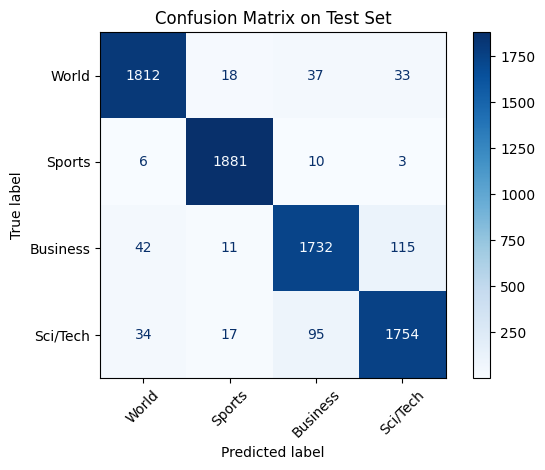

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 四個分類標籤 class
label_names = ['World', 'Sports', 'Business', 'Sci/Tech']  # AG News 的四類別

# 計算 confusion matrix
cm = confusion_matrix(test_label, test_preds)

# 顯示 confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

# 畫圖
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix on Test Set")
plt.xticks(rotation=45)  # 把 x 軸的標籤文字旋轉 45 度，讓它們更容易閱讀、不會重疊。ex: rotation=90 => 垂直顯示、rotation=0 => 不旋轉，水平顯示
plt.tight_layout()  # 自動調整圖表內部的 元素間距，避免文字、圖例、軸標籤等東西 重疊或被切到。在 matplotlib 畫圖時，如果你：標籤名稱比較長、字體放比較大、有旋轉文字（像你剛剛的 xticks(rotation=45)）、加了標題或圖例（legend），這些東西都可能導致 圖表元素之間擠在一起或被裁切掉！所以 plt.tight_layout() 會幫你自動調整整體版面配置，讓一切都比較剛好地排在圖內，不超出邊界。
# 建議！！！：幾乎所有 matplotlib 畫的圖 最後都可以加上一行 plt.tight_layout()，基本上沒有壞處。
plt.show()

# 🚀 可以發現模型對於 "Business" 和 "Sci/Tech" 最容易混淆，預測錯誤

In [6]:
# 用 sklearn 的 classification_report 來看各類別的 precision / recall / F1：
from sklearn.metrics import classification_report
print(classification_report(test_label, test_preds, target_names=label_names))


              precision    recall  f1-score   support

       World       0.96      0.95      0.96      1900
      Sports       0.98      0.99      0.98      1900
    Business       0.92      0.91      0.92      1900
    Sci/Tech       0.92      0.92      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



# 繪製出 Bert 對於一個文本的內容的 Attention Weight

device : cuda:0


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 模型載入完成並成功轉移到 GPU！
🥊 Model prediction: 3


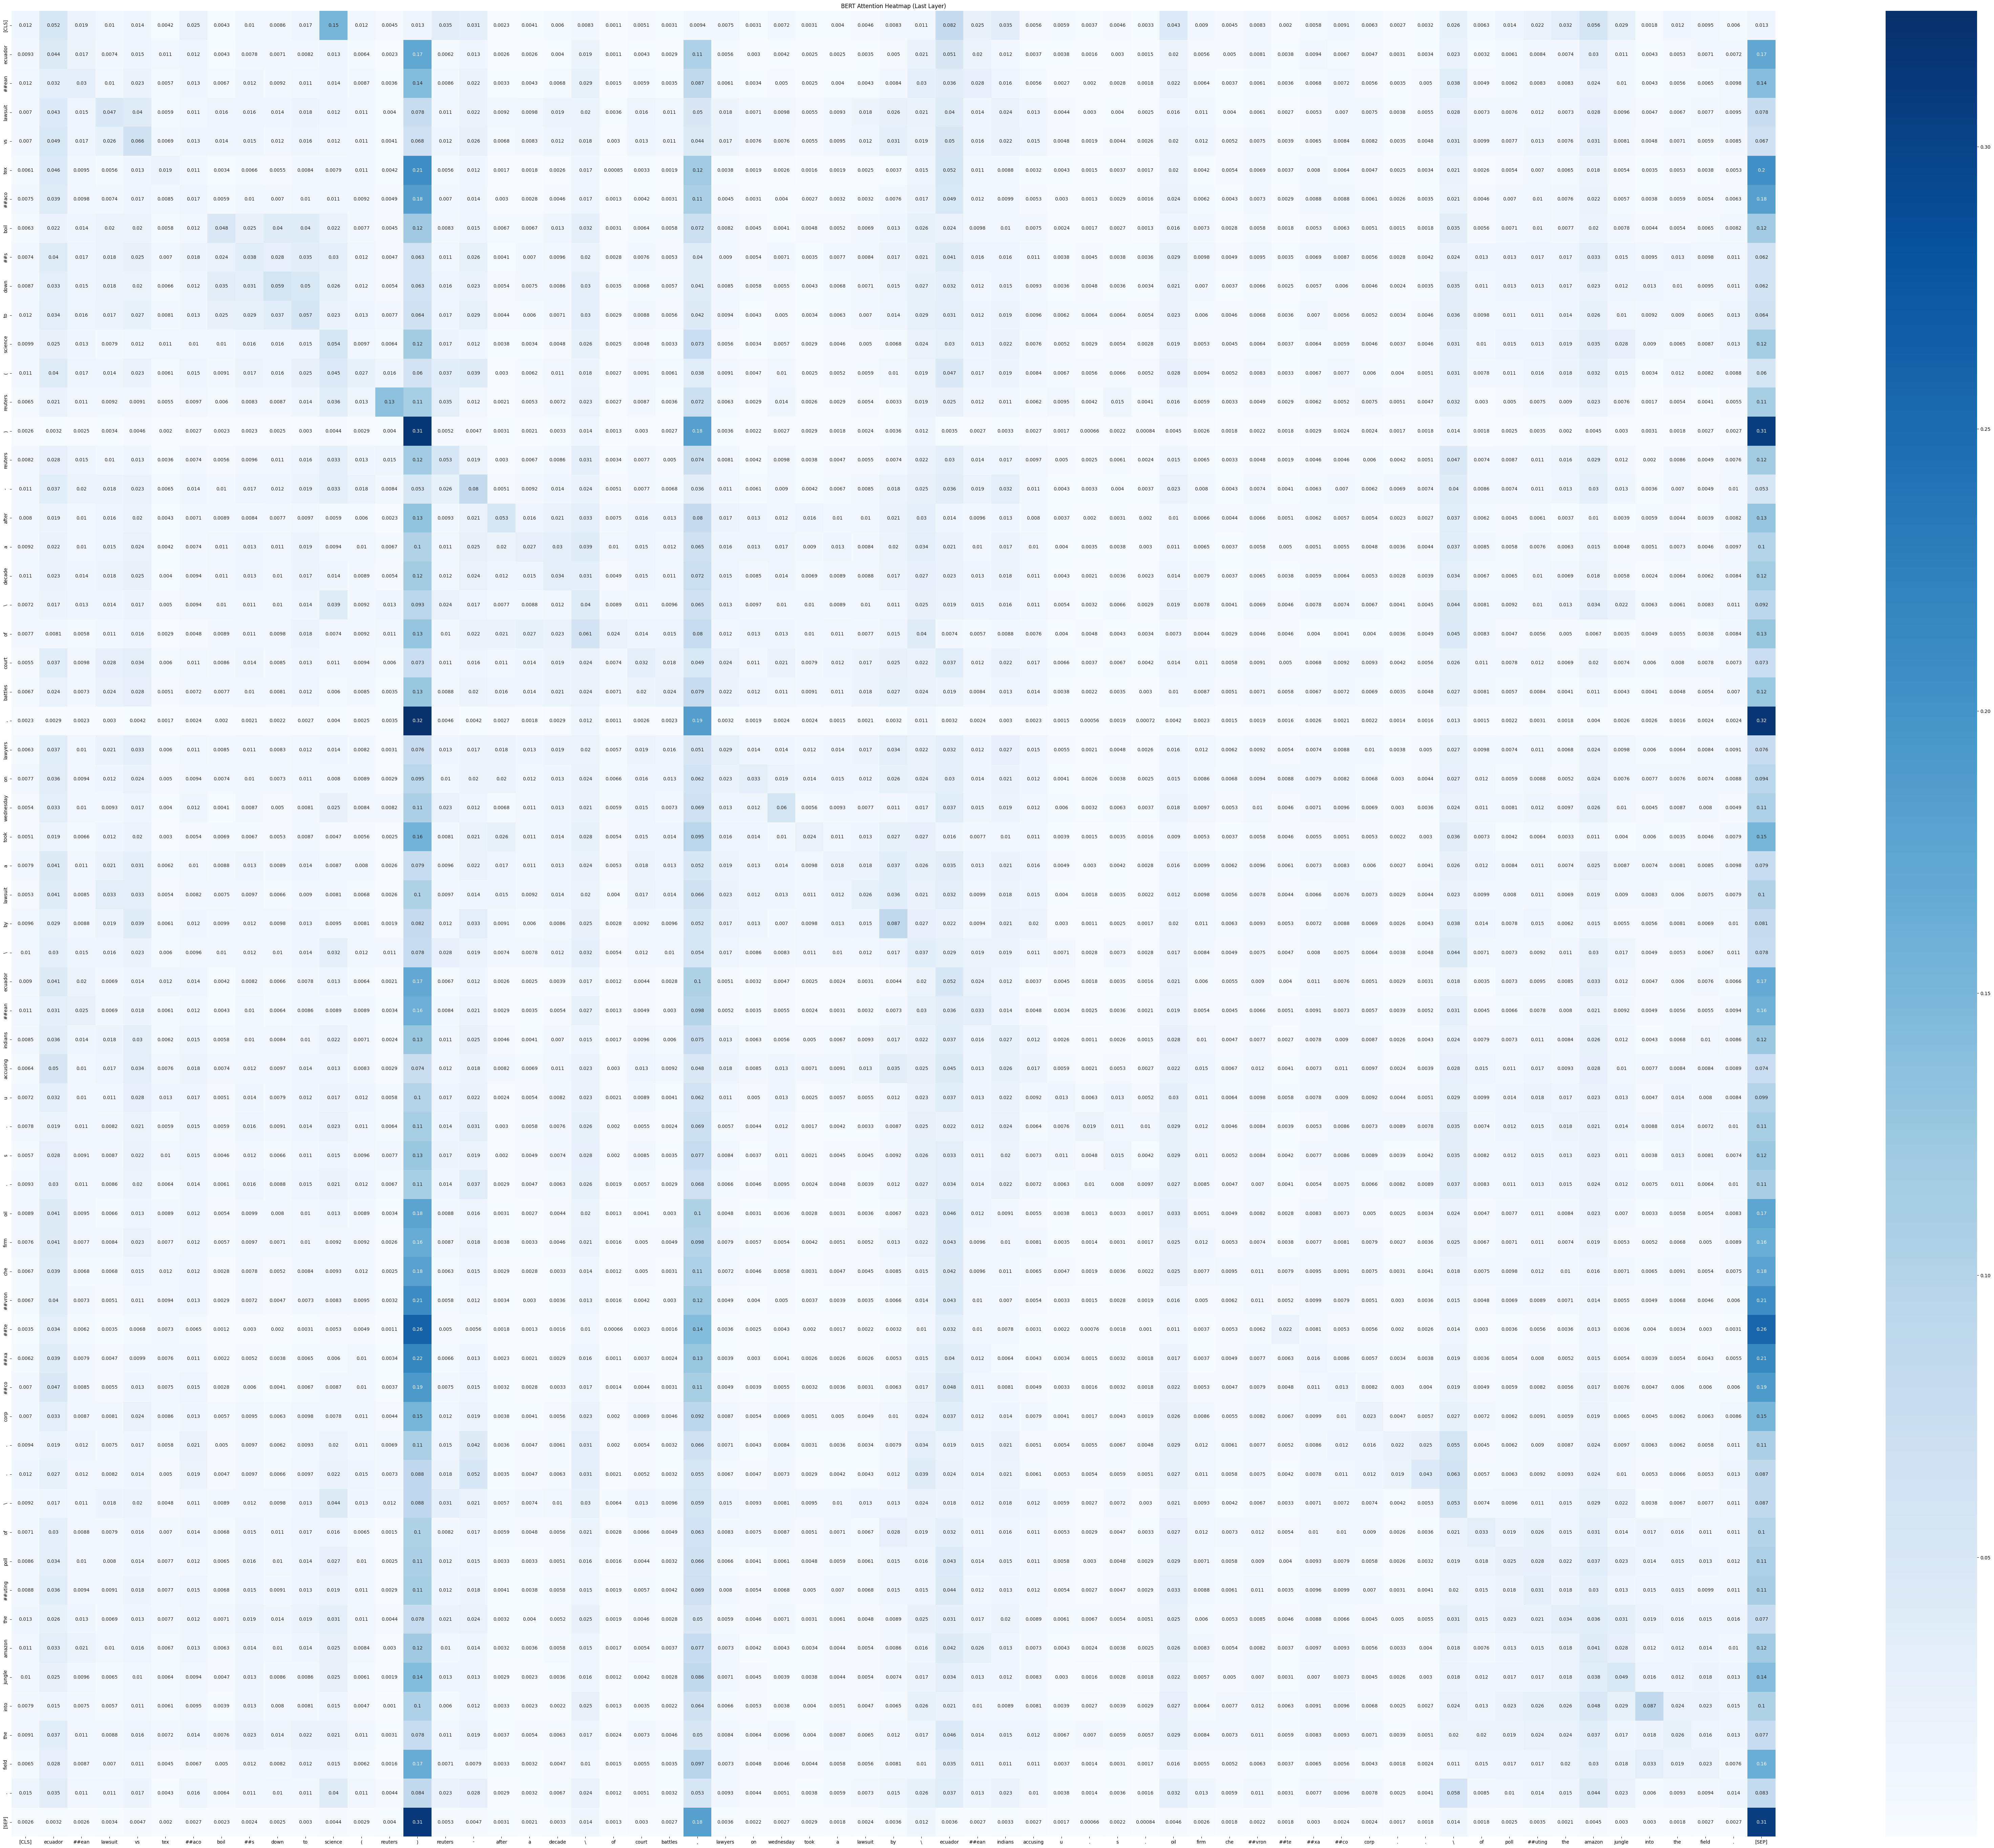

In [17]:
# 繪製模型的 attention weight，看看他在看這些預測錯誤的文章時，注意力集中在哪幾個關鍵詞
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu') # 指定device使用GPU
print(f"device : {device}") # 印出是否有抓到GPU，確保真的有成功抓到

# 載入 tokenizer（應該要和你訓練的 BERT 模型相同）
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# 設定訓練完的模型路徑
model_path = "/home/U113000001/best_model.pth"
# 載入 BERT 模型
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4, output_attentions=True)
# 先在 CPU 載入，因為用 GPU 載入模型出現 Runtime Error 運算超時
checkpoint = torch.load(model_path, map_location="cpu")
# 將參數載入到模型
model.load_state_dict(checkpoint)
# 再將模型轉移到 GPU 上
model.to(device)
model.eval()

print("✅ 模型載入完成並成功轉移到 GPU！")

# 丟一篇 model 預測錯的文章進來處理，並取得 attention weight
# 丟入預測錯誤的新聞文本
text = "Ecuadorean Lawsuit Vs Texaco Boils Down to Science (Reuters) Reuters - After a decade\of court battles, lawyers on Wednesday took a lawsuit by\Ecuadorean Indians accusing U.S. oil firm ChevronTexaco Corp..\of polluting the Amazon jungle into the field."

# Tokenize 文本
inputs = tokenizer(text, return_tensors="pt").to(device)  # 移動到 GPU

# 讓 BERT 模型處理文本，獲取 Attention Weights
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions  # 取得所有注意力層的權重
    logits = outputs.logits  # 取得模型的 logits（未經 softmax 處理的分數）
    
    # 取得預測結果：torch.max(logits, dim=1) 可得到 4 個 class 裡分數最高的 class index
    _, prediction = torch.max(logits, dim=1)

print(f"🥊 Model prediction: {prediction.item() + 1}") # 加一才是原本 1~4 的 class

# 繪製 Attention Heatmap
# 取得最後一層的注意力，轉移回 CPU 以便處理
last_layer_attention = attentions[-1].squeeze(0).mean(dim=0).cpu().numpy()

# 取得 tokenized 的字詞
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze().tolist())

# 繪製 heatmap
plt.figure(figsize=(84, 70))
sns.heatmap(last_layer_attention, xticklabels=tokens, yticklabels=tokens, cmap="Blues", annot=True)
plt.title("BERT Attention Heatmap (Last Layer)")
plt.show()

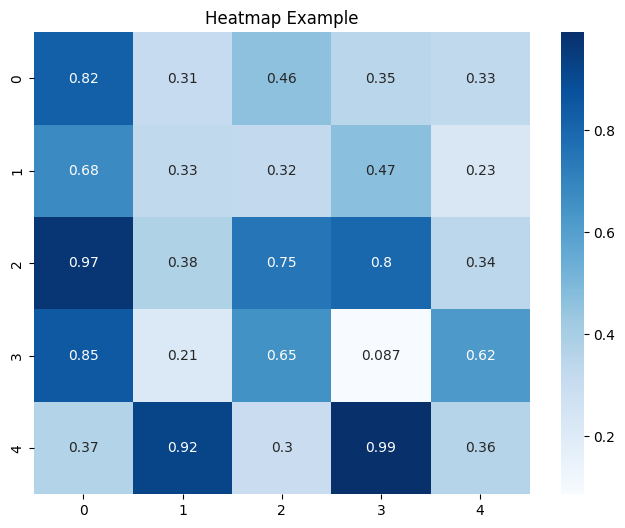

In [9]:
"""
seaborn 是 Python 的資料視覺化庫，它是基於 matplotlib，但提供 更美觀、更易用的統計圖表，適合用來做：
1. Heatmap（熱圖）：用來顯示 BERT Attention 權重
2. 散點圖、長條圖、折線圖 等
舉個例子，這是一個用 seaborn 繪製 Heatmap（熱圖） 的程式：
"""
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 創建一個 5x5 的隨機矩陣
data = np.random.rand(5, 5)

# 繪製 heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data, annot=True, cmap="Blues")
plt.title("Heatmap Example")
plt.show()


In [62]:
# 使用 gradio 來簡單 Demo
# 這個是簡單範例，測試看 gradio 能否正常運作
import gradio as gr

def func(text : str):
  return text

demo = gr.Interface(
    fn=func,
    inputs=gr.Textbox(placeholder="請輸入一段文字..."),
    outputs="label",
    examples=[["Take me to church"]]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://ceb437b8d384630ad6.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
# 如果發現任何有關於CUDA GPU 的操作都出現 Runtime Error，就先關掉 juypter notebook，關掉工作站重新連server

In [2]:
# 先將訓練完，最好的模型參數載入，才能進行 Demo 測試
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 設定模型路徑（Google Drive）
model_path = "/home/U113000001/best_model.pth"

# 載入 tokenizer（應該要和你訓練的 BERT 模型相同）
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 載入 BERT 模型
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
# 先在 CPU 載入，因為用 GPU 載入模型出現 Runtime Error 運算超時
checkpoint = torch.load(model_path, map_location="cpu")
# 將參數載入到模型
model.load_state_dict(checkpoint)
# 再將模型轉移到 GPU 上
model.to(device)
model.eval()

print("✅ 模型載入完成並成功轉移到 GPU！")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 模型載入完成並成功轉移到 GPU！


In [3]:
# 模型載入好後，就可以開始 Demo 了！
import gradio as gr
import torch.nn.functional as F

# 宣告一個Class對應主題的字典
class_to_topic = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# 定義背後處理函數
def predict(text):
    """ 用 BERT 預測文字的分類，回傳 softmax 機率 """
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits  # 取得 logits
    probs = F.softmax(logits, dim=1)  # 轉成機率

    # 回傳每個 class 對應的主題和機率
    # probs.shape[1]代表probs維度一的數量 => probs是個(1*4)的tensor，而dimension 1 的數量是 4 個(4個class)，所以 i = 0,1,2,3
    return {class_to_topic[i]: float(probs[0][i]) for i in range(probs.shape[1])}  # 直接回傳每個class softmax 後的機率

# 建立 Gradio 介面
demo = gr.Interface(
    fn=predict,  
    inputs=gr.Textbox(lines=3, placeholder="輸入一段文字"),  
    outputs=gr.Label(num_top_classes=4),  # 直接顯示 softmax 機率
    title="BERT 文字分類 Demo",
    description="輸入一段文字，BERT 會預測它的分類 (顯示機率)"
)

# 啟動 Web UI
demo.launch(share=True)

# 要用 public 的 URL 連結才能成功使用，也才能複製貼上東西，用juypter跑出來的介面無法貼上複製的東西到輸入框裡

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://16a7862b4c70988cff.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
